# CNN on Normalized Wafer Maps

The baseline showed engineered features handle geometrically clean signatures but blur together the diffuse classes (Loc / Edge-Loc / Random). A small CNN sees the full spatial layout and learns its own features.

Design choices:
- **Input encoding:** one-hot over {outside-wafer, pass, fail} — 3 channels — so the network distinguishes wafer edge from passing die instead of treating the map as ordinal intensities.
- **Class-balanced sampling:** a `WeightedRandomSampler` draws each class roughly equally per epoch, so the loss isn't dominated by "none".
- **Small network on purpose:** ~300k parameters. The maps are 64×64 with 3 discrete values — a ResNet-50 would be theater.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from src import data
from src.models import WaferCNN, WaferDataset

sns.set_theme(style="whitegrid")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

X_maps, y = data.load_labeled()
X_tr, X_te, y_tr, y_te = train_test_split(X_maps, y, test_size=0.2, stratify=y, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X_tr, y_tr, test_size=0.1, stratify=y_tr, random_state=42)
print(f"train {len(y_tr):,} / val {len(y_val):,} / test {len(y_te):,}")

device: cuda


train 124,524 / val 13,836 / test 34,590


In [2]:
def make_loader(X, y, train=False, batch_size=256):
    # WaferDataset one-hot encodes per batch — materializing the full float
    # tensor up front would cost ~8 GB of RAM for 173k maps
    ds = WaferDataset(X, y)
    if not train:
        return DataLoader(ds, batch_size=batch_size, num_workers=2)
    class_counts = np.bincount(y, minlength=len(data.CLASSES))
    weights = (1.0 / np.maximum(class_counts, 1))[y]
    sampler = WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double),
                                    num_samples=len(y), replacement=True)
    return DataLoader(ds, batch_size=batch_size, sampler=sampler, num_workers=2)

train_loader = make_loader(X_tr, y_tr, train=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_te, y_te)

In [3]:
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(device)).argmax(1).cpu())
            targets.append(yb)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

torch.manual_seed(42)
model = WaferCNN(n_classes=len(data.CLASSES)).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15)
loss_fn = nn.CrossEntropyLoss()

history = []
for epoch in range(15):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        opt.step()
        running += loss.item() * len(yb)
    sched.step()
    val_pred, val_true = evaluate(model, val_loader)
    # balanced accuracy = mean per-class recall — the metric that respects rare classes
    recalls = [ (val_pred[val_true == c] == c).mean() for c in range(len(data.CLASSES)) ]
    bal_acc = float(np.mean(recalls))
    history.append({"epoch": epoch, "train_loss": running / len(y_tr), "val_bal_acc": bal_acc})
    print(f"epoch {epoch:2d}  train_loss {running/len(y_tr):.4f}  val balanced-acc {bal_acc:.3f}")

torch.save(model.state_dict(), "../models/wafer_cnn.pt")

epoch  0  train_loss 0.6040  val balanced-acc 0.832


epoch  1  train_loss 0.2744  val balanced-acc 0.821


epoch  2  train_loss 0.1891  val balanced-acc 0.795


epoch  3  train_loss 0.1329  val balanced-acc 0.691


epoch  4  train_loss 0.0997  val balanced-acc 0.835


...

epoch 10  train_loss 0.0197  val balanced-acc 0.858


epoch 11  train_loss 0.0155  val balanced-acc 0.876


epoch 12  train_loss 0.0127  val balanced-acc 0.858


epoch 13  train_loss 0.0108  val balanced-acc 0.858


epoch 14  train_loss 0.0093  val balanced-acc 0.866


              precision    recall  f1-score   support

      Center      0.859     0.874     0.867       859
       Donut      0.825     0.766     0.794       111
    Edge-Loc      0.761     0.849     0.803      1038
   Edge-Ring      0.967     0.977     0.972      1936
         Loc      0.677     0.682     0.680       718
   Near-full      0.794     0.900     0.844        30
      Random      0.836     0.855     0.846       173
     Scratch      0.743     0.653     0.695       239
        none      0.989     0.985     0.987     29486

    accuracy                          0.967     34590
   macro avg      0.828     0.838     0.832     34590
weighted avg      0.968     0.967     0.968     34590



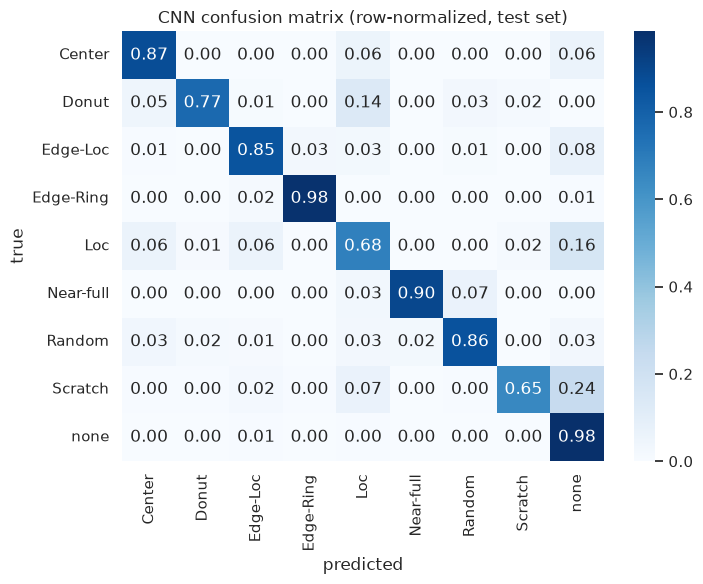

In [4]:
pred, true = evaluate(model, test_loader)
print(classification_report(true, pred, target_names=data.CLASSES, digits=3))

cm = confusion_matrix(true, pred, normalize="true")
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=data.CLASSES, yticklabels=data.CLASSES, ax=ax)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("CNN confusion matrix (row-normalized, test set)")
plt.tight_layout()
plt.savefig("../reports/figures/cnn_confusion.png", dpi=150)
plt.show()

### Where does the model still fail? Look at the actual wafers

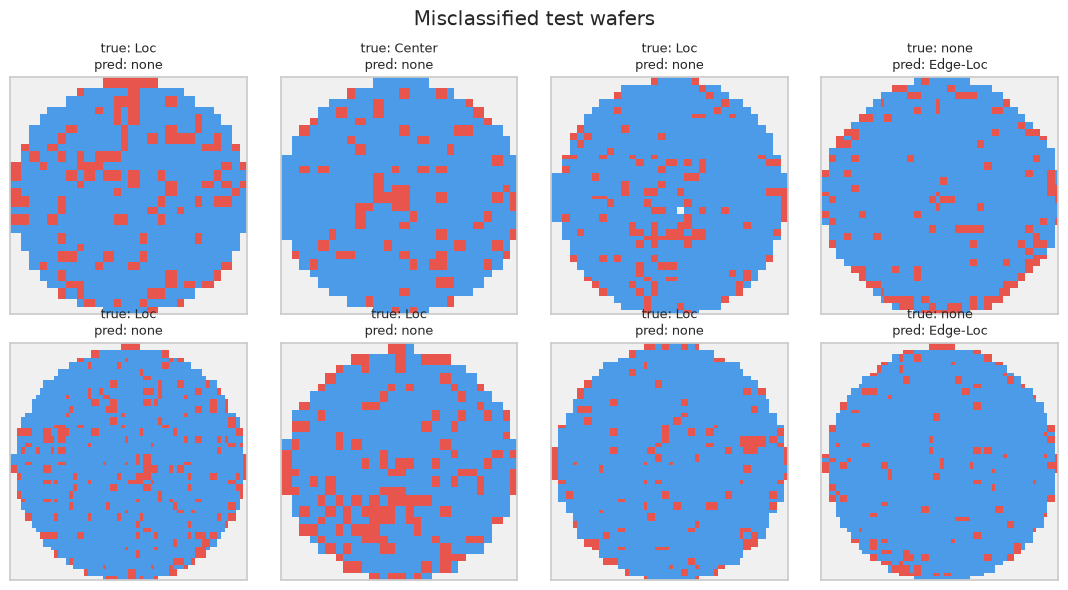

In [5]:
from matplotlib.colors import ListedColormap
wafer_cmap = ListedColormap(["#f0f0f0", "#4c9be8", "#e8554c"])

wrong = np.flatnonzero(pred != true)
rng = np.random.default_rng(1)
picks = rng.choice(wrong, size=min(8, len(wrong)), replace=False)
fig, axes = plt.subplots(2, 4, figsize=(11, 6))
for ax, i in zip(axes.ravel(), picks):
    ax.imshow(X_te[i], cmap=wafer_cmap, vmin=0, vmax=2)
    ax.set_title(f"true: {data.CLASSES[true[i]]}\npred: {data.CLASSES[pred[i]]}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Misclassified test wafers")
plt.tight_layout()
plt.savefig("../reports/figures/cnn_errors.png", dpi=150)
plt.show()

## Conclusions — honest comparison with the baseline

An important caveat first: the two evaluations aren't on identical test sets. The baseline was tested with "none" capped (4k of 9k test wafers), while the CNN faces the full production mix — 29.5k of 34.6k test wafers are "none" (85%). The CNN's task is closer to real deployment conditions.

What the numbers say:

- **On the realistic mix, the CNN holds macro-F1 (~0.83) while nearly eliminating false alarms on the dominant class** — "none" F1 is 0.987 (precision 0.989). At fab scale that matters most: with hundreds of thousands of clean wafers flowing past, even a 3% false-flag rate (the baseline's) would bury engineers in noise.
- **Scratch precision improved sharply** (0.51 → 0.74): the baseline over-called scratches; the CNN's learned spatial features are more specific. Scratch *recall* dipped (0.70 → 0.65) — thin, faint scratches remain the hardest signature at 64×64 resolution.
- **Geometric classes stay strong** (Edge-Ring 0.97 F1) and **Loc remains the weakest patterned class** for both models — evidence the difficulty is in the data (small, ambiguous clusters), not the model family.

The engineering takeaway: for this problem, a small CNN earns its place mainly through **false-alarm suppression at production class ratios**, not through headline accuracy. Interpretable features remain competitive for the clean geometric signatures — a hybrid (features for triage, CNN for confirmation) is a legitimate deployment option.

**Deployment sketch for a fab:** run the model on every sort/inline wafer map, auto-tag high-confidence signatures for SPC trending and excursion alarms, queue low-confidence maps for engineer review. The win is measured in reviewer hours saved and faster time-to-root-cause — not accuracy points.

### Limitations and next steps
- Labels are single-class; real wafers carry overlapping signatures (scratch **and** edge ring). Multi-label classification is the natural next step.
- Rotation/flip augmentation should lift Scratch and Loc recall (signatures are orientation-agnostic; the current model must learn each orientation from data).
- WM-811K's patterns are cleaner than day-one fab data; a real deployment needs a labeling campaign and drift monitoring as products and processes change.